In [1]:
import os

import numpy as np
import pandas as pd
import mdtraj as md

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from pymbar import timeseries

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [2]:
triples = []
base = "../results/03_free_energy_landscape/3VKI/md/simulations"

for seed in range(100):
    prefix = f"3VKI_seed_{seed}_prepared_fixed_N"
    run_dir = f"{base}/{prefix}"
    traj = f"{run_dir}/{prefix}_npt_prod_prot.dcd"
    top  = f"{run_dir}/{prefix}_prot.pdb"
    log  = f"{run_dir}/{prefix}_npt_prod.log"

    if all(os.path.exists(p) for p in (traj, top, log)):
        triples.append((seed, log, traj, top))

# Thermal energy (kT) in kJ/mol
kB = 1.380649e-23 * 6.02214076e23 / 1000.0
temperature = 300.0
kT = kB * temperature

energies_in_kT = []
ca_xyz_list = []     
frame_map = []       # Map each selected frame -> (traj_idx, original_frame_idx)
tops = []            # Topology paths aligned with trajs[]
trajs = []           # Trajectory paths aligned with tops[]

for traj_idx, (seed, log, traj, top) in enumerate(triples):
    # Potential energy time series (kJ/mol -> kT)
    data = pd.read_csv(log)
    At = data["Potential Energy (kJ/mole)"].values / kT

    # Detect equilibration and subsample statistically uncorrelated frames
    t0, g, Neff_max = timeseries.detect_equilibration(At)
    print(f"log: {os.path.basename(log)}, t0={t0}, g={g:.2f}, Neff={Neff_max:.1f}")

    A_t_equil = At[t0:]
    indices = timeseries.subsample_correlated_data(A_t_equil, g=g)
    energies_in_kT.append(A_t_equil[indices])

    # Load protein-only trajectory and extract CA coordinates
    frames = md.load(traj, top=top)
    ca = frames.atom_slice(frames.top.select("name CA"))
    ca_sel = ca[t0:][indices]
    ca_xyz_list.append(ca_sel.xyz)

    # Record the origin (traj_idx, frame_idx) for each selected frame
    origin_sel = np.arange(len(frames), dtype=int)[t0:][indices]
    frame_map.extend((traj_idx, int(f)) for f in origin_sel)

    trajs.append(traj)
    tops.append(top)

energies_in_kT = np.concatenate(energies_in_kT, axis=0)
ca_xyz = np.concatenate(ca_xyz_list, axis=0)         # (N_total, n_CA, 3)
frame_map = np.asarray(frame_map, dtype=int)         # (N_total, 2): [traj_idx, frame_idx]

log: 3VKI_seed_0_prepared_fixed_N_npt_prod.log, t0=77, g=1.24, Neff=3955.2
log: 3VKI_seed_1_prepared_fixed_N_npt_prod.log, t0=138, g=1.10, Neff=4416.6
log: 3VKI_seed_2_prepared_fixed_N_npt_prod.log, t0=0, g=1.00, Neff=5001.0
log: 3VKI_seed_3_prepared_fixed_N_npt_prod.log, t0=146, g=1.01, Neff=4811.1
log: 3VKI_seed_4_prepared_fixed_N_npt_prod.log, t0=0, g=1.00, Neff=5001.0
log: 3VKI_seed_5_prepared_fixed_N_npt_prod.log, t0=1, g=1.02, Neff=4905.0
log: 3VKI_seed_6_prepared_fixed_N_npt_prod.log, t0=31, g=1.04, Neff=4764.6
log: 3VKI_seed_7_prepared_fixed_N_npt_prod.log, t0=1, g=1.22, Neff=4089.2
log: 3VKI_seed_8_prepared_fixed_N_npt_prod.log, t0=138, g=1.04, Neff=4665.0
log: 3VKI_seed_9_prepared_fixed_N_npt_prod.log, t0=0, g=1.10, Neff=4545.9
log: 3VKI_seed_10_prepared_fixed_N_npt_prod.log, t0=0, g=1.01, Neff=4944.3
log: 3VKI_seed_11_prepared_fixed_N_npt_prod.log, t0=0, g=1.23, Neff=4068.5
log: 3VKI_seed_12_prepared_fixed_N_npt_prod.log, t0=0, g=1.03, Neff=4849.1
log: 3VKI_seed_13_prepared_

In [3]:
tmpl_full = md.load(trajs[0], top=tops[0])
tmpl_ca = tmpl_full.atom_slice(tmpl_full.top.select("name CA"))
top_ca = tmpl_ca.topology

uncorrelated_ca = md.Trajectory(ca_xyz, top_ca)

uncorrelated_ca_aln = uncorrelated_ca.superpose(uncorrelated_ca[0])

xyz = uncorrelated_ca_aln.xyz                                # (N, n_CA, 3)
xyz_flat = xyz.reshape(xyz.shape[0], -1)                     # (N, n_CA*3)

pca = PCA(n_components=2)
uncorrelated_pca_coords = pca.fit_transform(xyz_flat)

uncorrelated_energies = energies_in_kT

check_reference = pca.mean_.reshape(1, -1, 3)  # (1, n_CA, 3)

uncorrelated_ca_reference = uncorrelated_ca[0].slice([0])
uncorrelated_ca_reference.xyz = check_reference

uncorrelated_ca2 = uncorrelated_ca.superpose(uncorrelated_ca_reference)

pca_2 = PCA(n_components=2)
uncorrelated_pca_coords_2 = pca_2.fit_transform(
    uncorrelated_ca2.xyz.reshape(uncorrelated_ca2.n_frames, -1)
)

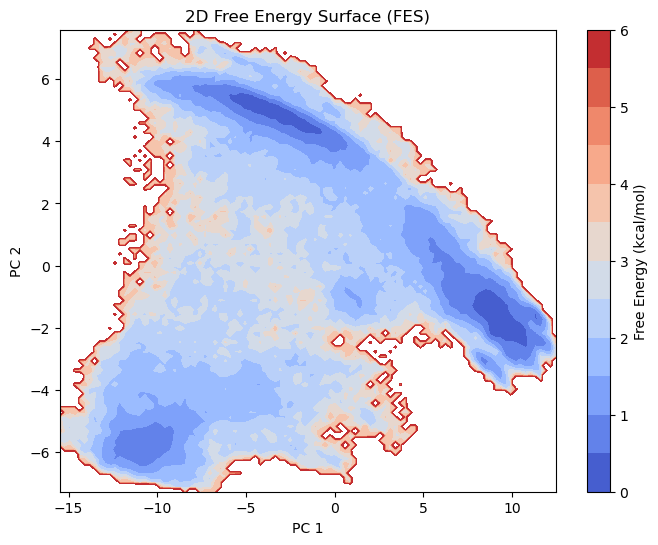

In [4]:
# Build a 2D free-energy surface (FES) from PCA coordinates
x = uncorrelated_pca_coords_2[:, 0]   # PC1
y = uncorrelated_pca_coords_2[:, 1]   # PC2

bins = 100
hist, xedges, yedges = np.histogram2d(x, y, bins=bins, density=True)

# Convert probability density to free energy (shifted so min = 0)
eps = 1e-9
fes_kT = -np.log(hist.T + eps)
fes_kT -= np.nanmin(fes_kT)

kT_to_kcal = 0.596
fes_kcal = fes_kT * kT_to_kcal

vmax = 6.0
levels = np.arange(0.0, vmax + 0.01, 0.5)

plt.figure(figsize=(8, 6))
contour = plt.contourf(
    xedges[:-1], yedges[:-1], fes_kcal,
    levels=levels, cmap="coolwarm", vmax=vmax
)
plt.colorbar(contour, label="Free Energy (kcal/mol)")
plt.title("2D Free Energy Surface (FES)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

In [5]:
def get_index_from_bin(i_bin, j_bin, x, y, xedges, yedges, verbose=True):
    """
    Given a 2D histogram bin (i_bin, j_bin), return the index of the data point
    closest to the bin center.

    Parameters
    ----------
    i_bin, j_bin : int
        Bin indices matching the FES matrix indexing (row=i_bin for y, col=j_bin for x).
    x, y : (N,) array-like
        Original 2D samples (e.g., PC1 and PC2 values) used to build the histogram/FES.
    xedges, yedges : array-like
        Bin edges returned by np.histogram2d(x, y, ...).
    verbose : bool
        If True, print a short message when the bin is empty or for debugging.

    Returns
    -------
    closest_index : int or None
        Index of the point closest to the bin center; None if the bin has no points.
    info : dict
        Bin bounds/center and point count:
        {
            "x_bin": [x_min, x_max],
            "y_bin": [y_min, y_max],
            "x_center": float,
            "y_center": float,
            "num_points": int
        }
    """
    n_y = len(yedges) - 1
    n_x = len(xedges) - 1

    if not (0 <= i_bin < n_y and 0 <= j_bin < n_x):
        raise ValueError(
            f"Bin index ({i_bin},{j_bin}) is out of range: "
            f"x bins [0,{n_x-1}], y bins [0,{n_y-1}]"
        )

    x_min, x_max = xedges[j_bin], xedges[j_bin + 1]
    y_min, y_max = yedges[i_bin], yedges[i_bin + 1]
    x_center = 0.5 * (x_min + x_max)
    y_center = 0.5 * (y_min + y_max)

    mask = (x >= x_min) & (x < x_max) & (y >= y_min) & (y < y_max)
    indices = np.where(mask)[0]

    info = {
        "x_bin": [x_min, x_max],
        "y_bin": [y_min, y_max],
        "x_center": x_center,
        "y_center": y_center,
        "num_points": int(len(indices)),
    }

    if len(indices) == 0:
        if verbose:
            print(f"[WARN] Empty bin ({i_bin},{j_bin}).")
        return None, info

    distances = np.sqrt((x[indices] - x_center) ** 2 + (y[indices] - y_center) ** 2)
    closest_index = int(indices[np.argmin(distances)])

    if verbose:
        print(
            f"Bin({i_bin},{j_bin}): n={len(indices)}, closest raw index={closest_index}, "
            f"x in [{x_min:.3f},{x_max:.3f}), y in [{y_min:.3f},{y_max:.3f})"
        )

    return closest_index, info

def find_diverse_basins(
    fes,
    x, y, xedges, yedges,
    n_basins=8,
    mask_radius=9,
    n_per_basin=10,
    verbose=True,
):
    """
    Greedy basin picking from an FES grid:
    - Find the current global minimum (unmasked).
    - Within a square neighborhood, rank bins by energy (low to high).
    - Keep bins that contain at least one raw sample, and collect up to n_per_basin.
    - Mask the whole neighborhood so the next basin is spatially separated.

    Parameters
    ----------
    fes : (Ny, Nx) array-like
        FES grid (e.g., in kT or kcal/mol). Lower is better.
    x, y, xedges, yedges : array-like
        Raw samples + histogram edges used to locate representative frames per bin.
    n_basins : int
        Number of separated basins to find.
    mask_radius : int
        Half-width of the masked square neighborhood around each basin center.
    n_per_basin : int
        Max number of non-empty low-energy bins to pick per basin.
    verbose : bool
        If True, print messages when skipping empty bins.

    Returns
    -------
    df_all : pandas.DataFrame
        One row per selected bin with representative raw index and bin metadata.
    """
    fes_work = fes.copy()
    height, width = fes.shape
    all_points = []
    global_rank = 1

    for basin_id in range(1, n_basins + 1):
        min_idx_1d = np.argmin(fes_work)
        if not np.isfinite(fes_work.ravel()[min_idx_1d]):
            print(f"[INFO] No more finite basins. Stopped at basin {basin_id - 1}.")
            break

        i_center, j_center = np.unravel_index(min_idx_1d, fes.shape)

        half = mask_radius
        i_min = max(0, i_center - half)
        i_max = min(height, i_center + half + 1)
        j_min = max(0, j_center - half)
        j_max = min(width, j_center + half + 1)

        basin_region = fes[i_min:i_max, j_min:j_max]
        valid_region_mask = np.isfinite(fes_work[i_min:i_max, j_min:j_max])

        rel_i, rel_j = np.where(valid_region_mask)
        if len(rel_i) == 0:
            print(f"[INFO] Basin {basin_id}: region is fully masked; skipping.")
            continue

        values = basin_region[rel_i, rel_j]
        sort_idx = np.argsort(values)

        basin_points = []
        candidate_pos = 0
        while len(basin_points) < n_per_basin and candidate_pos < len(sort_idx):
            idx = sort_idx[candidate_pos]
            i_bin = int(rel_i[idx] + i_min)
            j_bin = int(rel_j[idx] + j_min)
            val = values[idx]

            closest_index, info = get_index_from_bin(
                i_bin, j_bin, x, y, xedges, yedges, verbose=verbose
            )

            if closest_index is not None:
                basin_points.append(
                    {
                        "basin_id": int(basin_id),
                        "rank_in_basin": int(len(basin_points) + 1),
                        "rank_global": int(global_rank),
                        "i_bin": int(i_bin),
                        "j_bin": int(j_bin),
                        "value": val,
                        "raw_index": int(closest_index),
                        "x_center": info["x_center"],
                        "y_center": info["y_center"],
                        "x_bin_min": info["x_bin"][0],
                        "x_bin_max": info["x_bin"][1],
                        "y_bin_min": info["y_bin"][0],
                        "y_bin_max": info["y_bin"][1],
                        "num_points": info["num_points"],
                        "is_valid": True,
                    }
                )
                global_rank += 1
            else:
                if verbose:
                    print(f"[INFO] Skip empty bin ({i_bin},{j_bin}).")

            candidate_pos += 1

        if len(basin_points) == 0:
            print(f"[INFO] Basin {basin_id}: all low-energy bins are empty; skipping.")
            fes_work[i_min:i_max, j_min:j_max] = np.inf
            continue

        actual_min_value = basin_points[0]["value"]

        fes_work[i_min:i_max, j_min:j_max] = np.inf
        all_points.extend(basin_points)

        print(
            f"Basin {basin_id:2d}: min={actual_min_value:6.3f} @ "
            f"({basin_points[0]['i_bin']:3d},{basin_points[0]['j_bin']:3d}); "
            f"valid bins in region={len(values):4d}, picked={len(basin_points)}"
        )

    return pd.DataFrame(all_points)


def save_full_frame_from_global_index(global_index: int, out_pdb: str, atom_sel: str = "protein"):
    """
    Save a single frame (by a global index) as PDB.

    Notes
    -----
    Expects the following globals to be defined in your session/script:
    - frame_map: dict[int -> (traj_idx, frame_idx)]
    - trajs: list of trajectory file paths
    - tops:  list of topology file paths
    """
    traj_idx, frame_idx = frame_map[int(global_index)]
    fr = md.load_frame(trajs[int(traj_idx)], index=int(frame_idx), top=tops[int(traj_idx)])
    if atom_sel is not None:
        fr = fr.atom_slice(fr.top.select(atom_sel))
    fr.save_pdb(out_pdb)

In [6]:
df_results = find_diverse_basins(fes_kcal, uncorrelated_pca_coords_2[:, 0], uncorrelated_pca_coords_2[:, 1], xedges, yedges,
                                 n_basins=20,
                                 mask_radius=5,
                                 n_per_basin=1,   
                                 verbose=False)

Basin  1: min= 0.000 @ ( 35, 88); valid bins in region= 121, picked=1
Basin  2: min= 0.156 @ ( 82, 42); valid bins in region= 121, picked=1
Basin  3: min= 0.229 @ ( 41, 87); valid bins in region=  71, picked=1
Basin  4: min= 0.273 @ ( 78, 49); valid bins in region=  93, picked=1
Basin  5: min= 0.357 @ ( 84, 36); valid bins in region=  76, picked=1
Basin  6: min= 0.397 @ ( 38, 95); valid bins in region=  69, picked=1
Basin  7: min= 0.545 @ ( 40, 81); valid bins in region=  67, picked=1
Basin  8: min= 0.581 @ ( 31, 94); valid bins in region=  62, picked=1
Basin  9: min= 0.635 @ (  9, 16); valid bins in region= 121, picked=1
Basin 10: min= 0.690 @ ( 76, 55); valid bins in region=  76, picked=1
Basin 11: min= 0.709 @ ( 46, 81); valid bins in region=  61, picked=1
Basin 12: min= 0.815 @ ( 86, 30); valid bins in region=  76, picked=1
Basin 13: min= 0.838 @ ( 12, 22); valid bins in region=  81, picked=1
Basin 14: min= 0.858 @ ( 28, 85); valid bins in region=  81, picked=1
Basin 15: min= 0.862

In [7]:
os.makedirs("./structures", exist_ok=True)

In [8]:
for _, row in df_results[:20].iterrows():
    gidx = row["raw_index"]
    if pd.isna(gidx):
        continue
    basin_id = int(row["basin_id"])
    r_in = int(row["rank_in_basin"])
    out_pdb = f"./structures/basin{basin_id:02d}_repr{r_in:02d}_gidx{int(gidx)}.pdb"
    save_full_frame_from_global_index(int(gidx), str(out_pdb), atom_sel="protein")